# CUSTOMER LIFETIME VALUE

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor, BaggingRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import cross_validate, cross_val_score

from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, median_absolute_error)

import pickle

# Import Data

In [2]:
clv_df = pd.read_csv('data_customer_lifetime_value.csv')
clv_df

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2.0,90.0,571.479602,11828.0,10083.486880
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6.0,62.0,114.514440,44762.0,4943.386117
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2.0,62.0,257.248789,21514.0,11981.984810
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1.0,116.0,556.800000,17913.0,4550.856045
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1.0,62.0,355.820799,19030.0,2372.155492
...,...,...,...,...,...,...,...,...,...,...,...
5664,Four-Door Car,Basic,Offer4,Unemployed,Single,High School or Below,1.0,74.0,532.800000,0.0,2442.216651
5665,Four-Door Car,Premium,Offer1,Employed,Divorced,Bachelor,2.0,109.0,523.200000,27778.0,12904.943360
5666,Four-Door Car,Basic,Offer1,Employed,Single,Bachelor,1.0,62.0,44.780402,84658.0,2447.053134
5667,Luxury SUV,Extended,Offer2,Employed,Divorced,Master,7.0,239.0,1294.700423,22705.0,19160.989940


## Data Exploration

In [ ]:
# DUPLICATE VALUE
clv_df.duplicated().sum()

np.int64(618)

In [7]:
# NULL VALUE
clv_df.isna().sum()

Vehicle Class              0
Coverage                   0
Renew Offer Type           0
EmploymentStatus           0
Marital Status             0
Education                  0
Number of Policies         0
Monthly Premium Auto       0
Total Claim Amount         0
Income                     0
Customer Lifetime Value    0
dtype: int64

In [8]:
clv_df.dtypes

Vehicle Class                  str
Coverage                       str
Renew Offer Type               str
EmploymentStatus               str
Marital Status                 str
Education                      str
Number of Policies         float64
Monthly Premium Auto       float64
Total Claim Amount         float64
Income                     float64
Customer Lifetime Value    float64
dtype: object

In [9]:
for i in clv_df.columns:
    print(i)
    display(clv_df[i].value_counts())
    print("="*100)

Vehicle Class


Vehicle Class
Four-Door Car    2858
Two-Door Car     1186
SUV              1096
Sports Car        307
Luxury SUV        115
Luxury Car        107
Name: count, dtype: int64

Coverage


Coverage
Basic       3477
Extended    1704
Premium      488
Name: count, dtype: int64

Renew Offer Type


Renew Offer Type
Offer1    2292
Offer2    1835
Offer3     900
Offer4     642
Name: count, dtype: int64

EmploymentStatus


EmploymentStatus
Employed         3541
Unemployed       1429
Medical Leave     267
Disabled          252
Retired           180
Name: count, dtype: int64

Marital Status


Marital Status
Married     3305
Single      1514
Divorced     850
Name: count, dtype: int64

Education


Education
Bachelor                1703
College                 1660
High School or Below    1620
Master                   460
Doctor                   226
Name: count, dtype: int64

Number of Policies


Number of Policies
1.0    2008
2.0    1413
3.0     727
7.0     271
5.0     270
9.0     264
4.0     251
6.0     236
8.0     229
Name: count, dtype: int64

Monthly Premium Auto


Monthly Premium Auto
65.0     217
71.0     203
66.0     186
63.0     185
69.0     185
        ... 
284.0      1
164.0      1
297.0      1
177.0      1
296.0      1
Name: count, Length: 191, dtype: int64

Total Claim Amount


Total Claim Amount
316.800000    70
292.800000    70
331.200000    68
312.000000    65
350.400000    62
              ..
391.636628     1
498.159874     1
446.084760     1
44.780402      1
161.615740     1
Name: count, Length: 3274, dtype: int64

Income


Income
0.0        1429
95697.0       9
11828.0       6
74454.0       6
48567.0       6
           ... 
79655.0       1
30595.0       1
27778.0       1
84658.0       1
60184.0       1
Name: count, Length: 3625, dtype: int64

Customer Lifetime Value


Customer Lifetime Value
10083.486880    6
5595.389905     6
5015.009472     6
8717.049833     6
2725.356404     6
               ..
8114.409136     1
2442.216651     1
12904.943360    1
2447.053134     1
7664.219255     1
Name: count, Length: 5049, dtype: int64

# Exploratory Data Analysis (EDA)

In [10]:
clv_df['Customer Lifetime Value'].describe()

count     5669.000000
mean      8029.874592
std       6916.708246
min       1898.007675
25%       3954.344534
50%       5800.188903
75%       9031.214859
max      83325.381190
Name: Customer Lifetime Value, dtype: float64

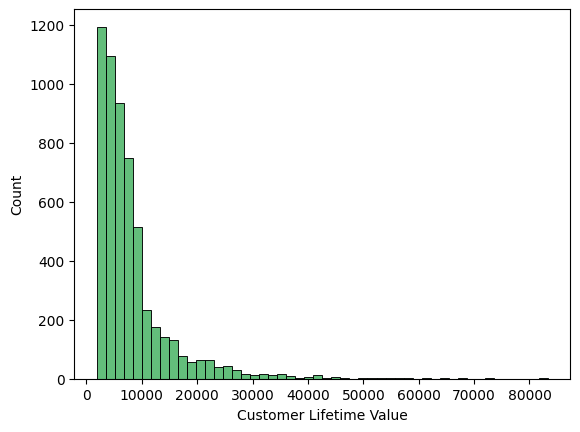

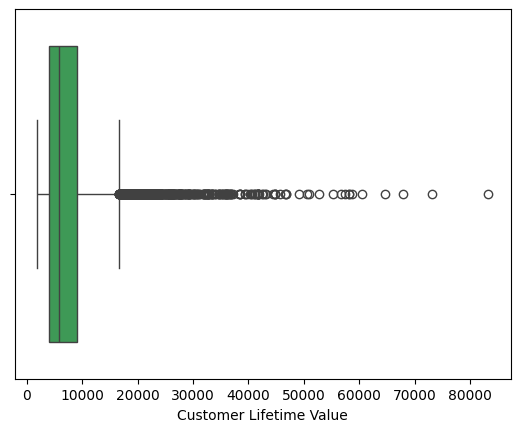

np.float64(3.06110718900048)

In [ ]:
# Histogram Raw

sns.histplot(clv_df['Customer Lifetime Value'], bins=50, color='#2fa84f')
plt.show()
sns.boxplot(clv_df[['Customer Lifetime Value']], x='Customer Lifetime Value', color='#2fa84f')
plt.show()
display(clv_df['Customer Lifetime Value'].skew())

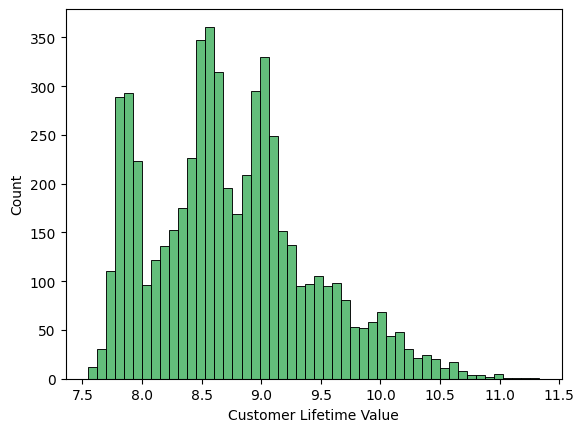

np.float64(0.5624578598710939)

In [12]:
# Histogram Log

sns.histplot(np.log(clv_df['Customer Lifetime Value']), bins=50, color='#2fa84f')
plt.show()
display(np.log(clv_df['Customer Lifetime Value']).skew())

In [13]:
# Data Types
clv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Vehicle Class            5669 non-null   str    
 1   Coverage                 5669 non-null   str    
 2   Renew Offer Type         5669 non-null   str    
 3   EmploymentStatus         5669 non-null   str    
 4   Marital Status           5669 non-null   str    
 5   Education                5669 non-null   str    
 6   Number of Policies       5669 non-null   float64
 7   Monthly Premium Auto     5669 non-null   float64
 8   Total Claim Amount       5669 non-null   float64
 9   Income                   5669 non-null   float64
 10  Customer Lifetime Value  5669 non-null   float64
dtypes: float64(5), str(6)
memory usage: 759.3 KB


## Numerical Feature

Heatmap Numeric Category


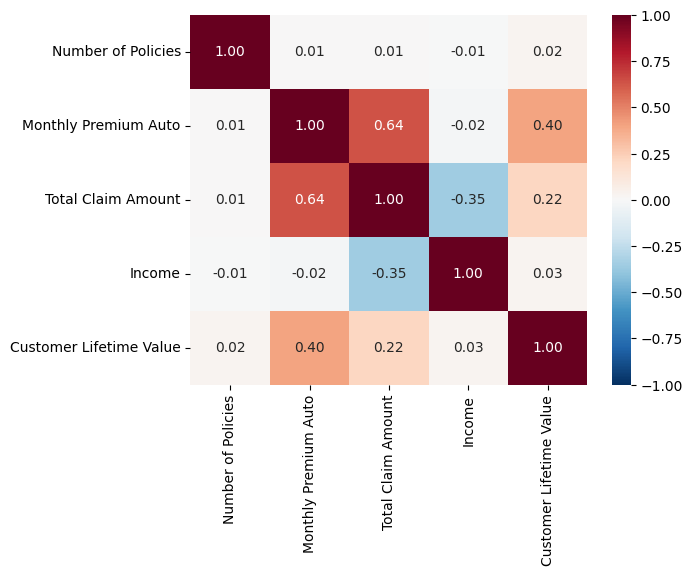

In [ ]:
# Correlation Of Numerical Features

print('Heatmap Numeric Category')
sns.heatmap(clv_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.show()

Number of Policies


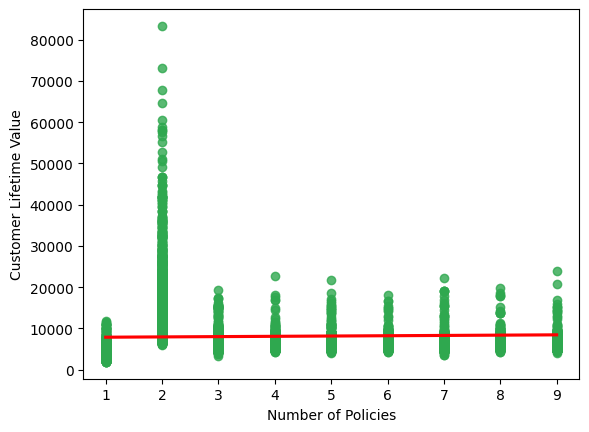

Monthly Premium Auto


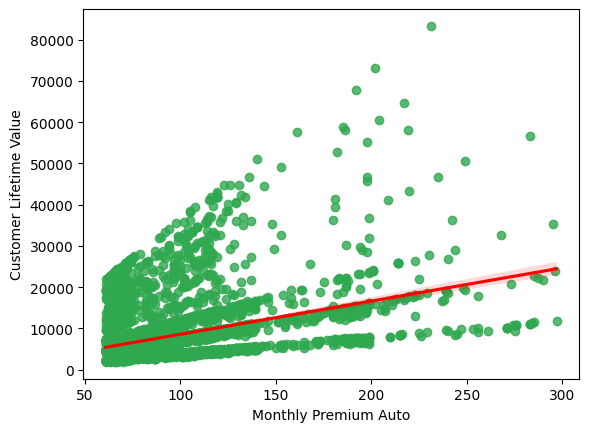

Total Claim Amount


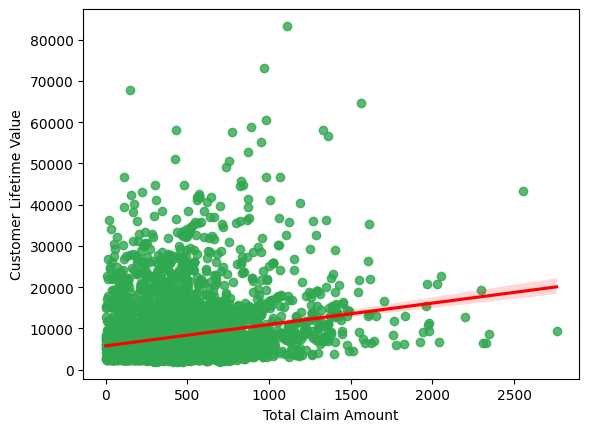

Income


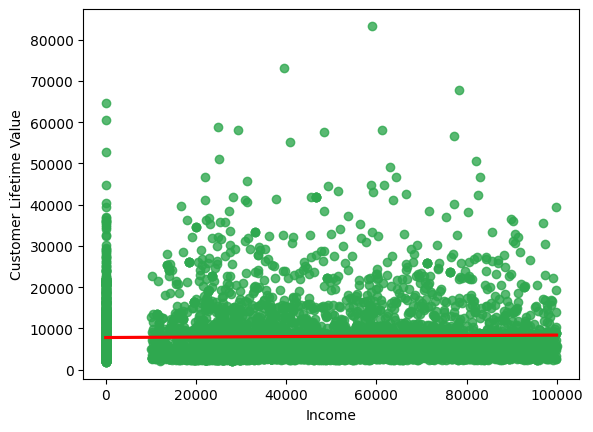

In [15]:
for i in clv_df.select_dtypes(include=['float64']):
    if 'Customer Lifetime Value' not in i:
        print(i)
        sns.regplot(x=i, y='Customer Lifetime Value', data=clv_df, line_kws={'color': 'red'}, scatter_kws={'color': '#2fa84f'})
        plt.show()
        print("====="*30)

## Categorical Feature

Number of Policies


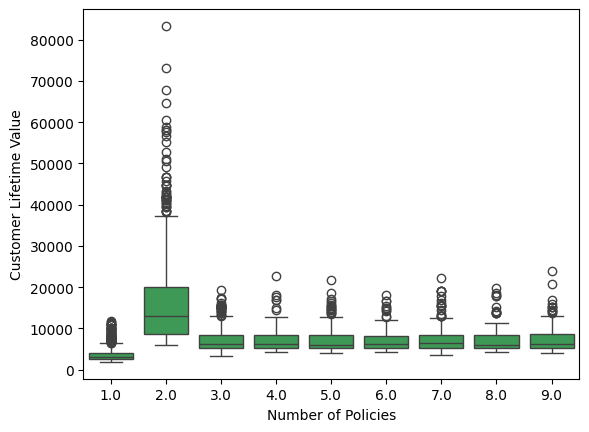

In [16]:
# Feature Number of Policies as Categorical Feature

print('Number of Policies')
sns.boxplot(x='Number of Policies', y='Customer Lifetime Value', data=clv_df, color='#2fa84f')
plt.show()

Vehicle Class


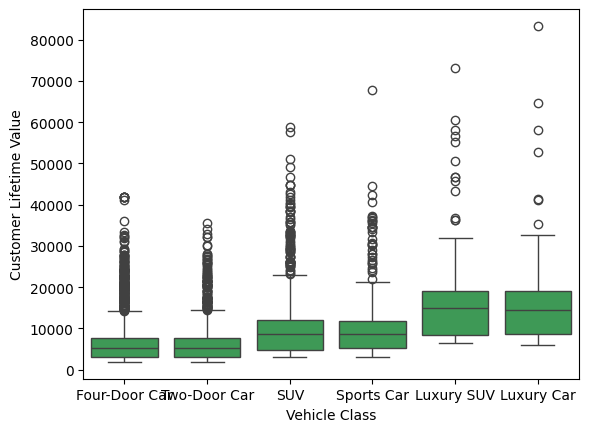

Coverage


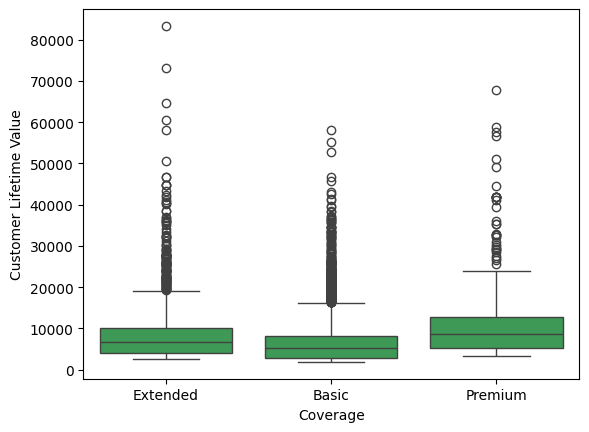

Renew Offer Type


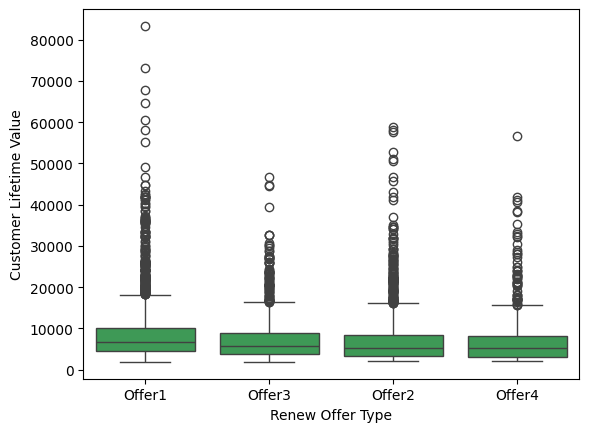

EmploymentStatus


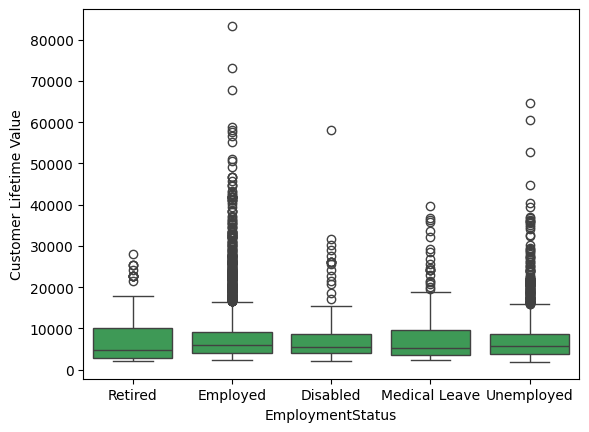

Marital Status


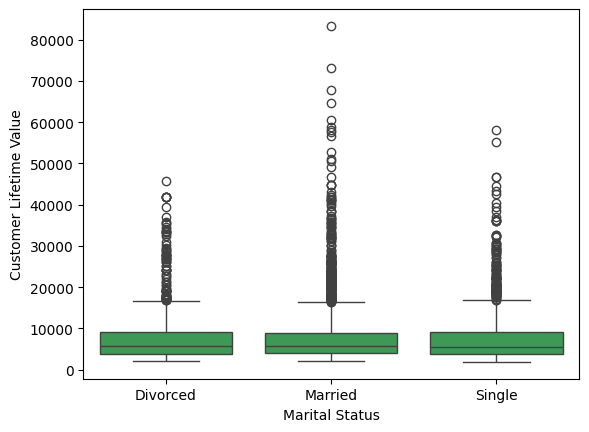

Education


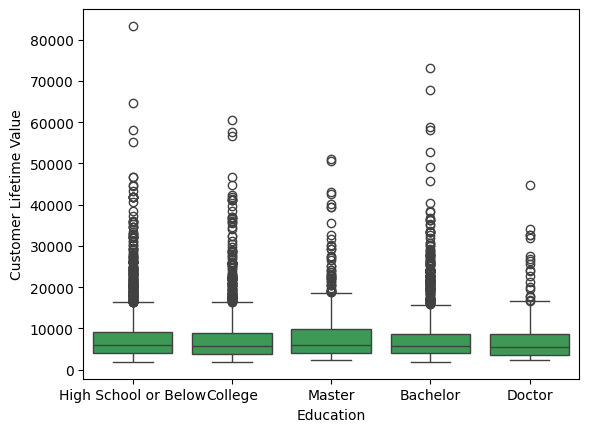

In [17]:
for i in clv_df.select_dtypes(include=['str']):
    print(i)
    sns.boxplot(x=i, y='Customer Lifetime Value', data=clv_df, color='#2fa84f')
    plt.show()
    print("====="*30)

## Multicollinearity

Vehicle Class


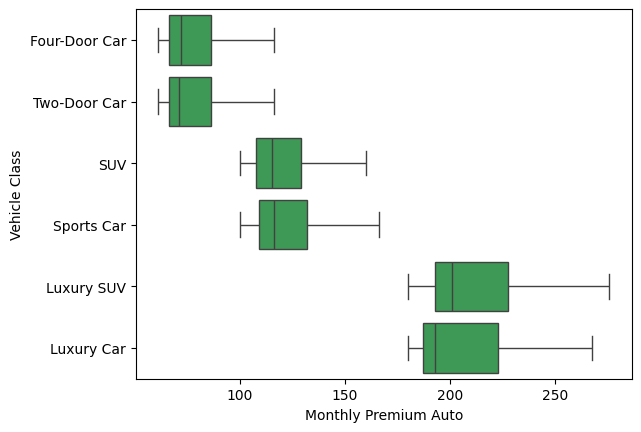

Coverage


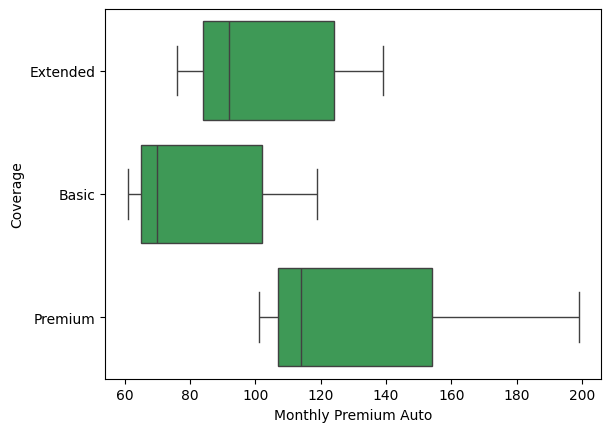

In [18]:
# Correlation Between Two Featurues

for i in ['Vehicle Class', 'Coverage']:
    print(i)
    sns.boxplot(x='Monthly Premium Auto', y=i, data=clv_df, showfliers=False, color='#2fa84f')
    plt.show()
    print("====="*30)

In [19]:
# Generalization

dummies = pd.get_dummies(clv_df[clv_df.select_dtypes(include=['str']).columns], drop_first=True)
X = pd.concat([clv_df[clv_df.select_dtypes(include=['float']).columns.drop('Customer Lifetime Value')], dummies], axis=1)
X = X.astype('float')
vif_input = add_constant(X)
vif_input

,const,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Vehicle Class_Luxury Car,Vehicle Class_Luxury SUV,Vehicle Class_SUV,Vehicle Class_Sports Car,Vehicle Class_Two-Door Car,...,EmploymentStatus_Employed,EmploymentStatus_Medical Leave,EmploymentStatus_Retired,EmploymentStatus_Unemployed,Marital Status_Married,Marital Status_Single,Education_College,Education_Doctor,Education_High School or Below,Education_Master
0,1.0,2.0,90.0,571.479602,11828.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,6.0,62.0,114.514440,44762.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,1.0,2.0,62.0,257.248789,21514.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1.0,1.0,116.0,556.800000,17913.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1.0,62.0,355.820799,19030.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5664,1.0,1.0,74.0,532.800000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
5665,1.0,2.0,109.0,523.200000,27778.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5666,1.0,1.0,62.0,44.780402,84658.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5667,1.0,7.0,239.0,1294.700423,22705.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
# Variance Inflation Factor

vif_list = []
for i in range(vif_input.shape[1]):
    vif_list.append(variance_inflation_factor(vif_input.values, i))

vif_table = pd.DataFrame()
vif_table['feature'] = vif_input.columns
vif_table['VIF'] = vif_list
vif_table = vif_table[vif_table['feature']!='const']
vif_table = vif_table.sort_values('VIF', ascending=False)
vif_table

,feature,VIF
2,Monthly Premium Auto,26.982562
6,Vehicle Class_Luxury SUV,8.670853
5,Vehicle Class_Luxury Car,7.986979
7,Vehicle Class_SUV,7.532404
15,EmploymentStatus_Employed,6.791874
18,EmploymentStatus_Unemployed,5.502984
11,Coverage_Premium,5.111009
8,Vehicle Class_Sports Car,3.226091
4,Income,3.112450
10,Coverage_Extended,2.970247


# Data Cleaning

## Drop Duplicate

In [23]:
clv_df = clv_df.drop_duplicates()
clv_df

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2.0,90.0,571.479602,11828.0,10083.486880
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6.0,62.0,114.514440,44762.0,4943.386117
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2.0,62.0,257.248789,21514.0,11981.984810
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1.0,116.0,556.800000,17913.0,4550.856045
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1.0,62.0,355.820799,19030.0,2372.155492
...,...,...,...,...,...,...,...,...,...,...,...
5663,Four-Door Car,Basic,Offer1,Employed,Married,High School or Below,2.0,69.0,446.084760,30595.0,8114.409136
5664,Four-Door Car,Basic,Offer4,Unemployed,Single,High School or Below,1.0,74.0,532.800000,0.0,2442.216651
5665,Four-Door Car,Premium,Offer1,Employed,Divorced,Bachelor,2.0,109.0,523.200000,27778.0,12904.943360
5666,Four-Door Car,Basic,Offer1,Employed,Single,Bachelor,1.0,62.0,44.780402,84658.0,2447.053134


## Convert Data Type

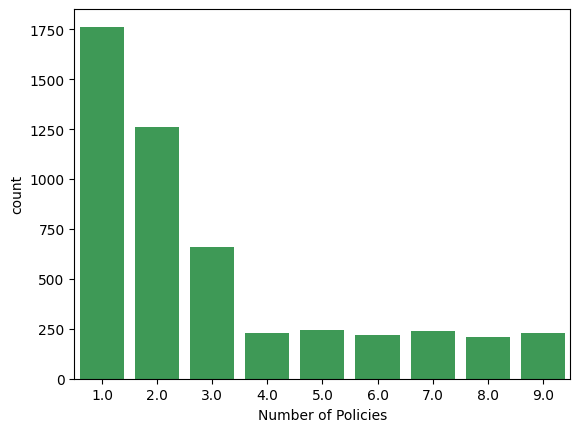

In [24]:
# Convert Number of Policies Feature from Numerical to Categorical Data
sns.countplot(data=clv_df, x='Number of Policies', color='#2fa84f')
plt.show()

In [25]:
clv_df['Policy Bin'] = pd.cut(clv_df['Number of Policies'],
                              bins=[0, 1, 2, 99],
                              labels=['1', '2', '3+']).astype(str)

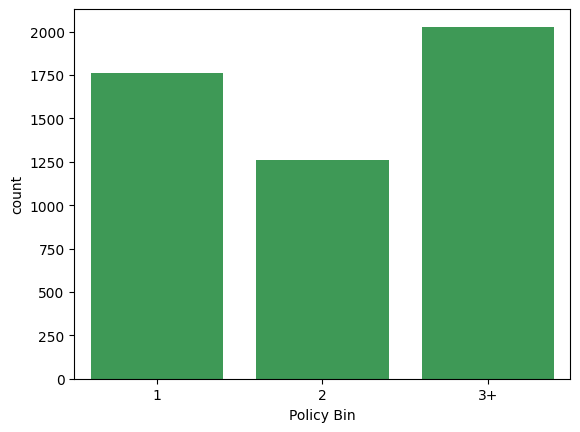

In [26]:
sns.countplot(data=clv_df, x='Policy Bin', color='#2fa84f', order=['1', '2', '3+'])
plt.show()

# Split Train and Test

## Split Data

In [27]:
target = 'Customer Lifetime Value'
X = clv_df.drop(columns=[target, 'Number of Policies']) 
y = clv_df[target]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Engineering

In [29]:
preprocessor = ColumnTransformer([
    ('Categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), clv_df.select_dtypes(include=['str']).columns),
    ('Numerical', StandardScaler(), clv_df.select_dtypes(include=['float64']).columns.drop(['Customer Lifetime Value', 'Number of Policies']))
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Categorical', ...), ('Numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [30]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Categorical', ...), ('Numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3

## Evaluate Encoding

In [31]:
X_train_raw = clv_df.drop(columns=[target, 'Policy Bin']) 
X_train_raw = X_train_raw.loc[X_train.index]


preprocessor_raw = ColumnTransformer([
    ('Categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), clv_df.select_dtypes(include=['str']).columns.drop(['Policy Bin'])),
    ('Numerical', StandardScaler(), clv_df.select_dtypes(include=['float64']).columns.drop(['Customer Lifetime Value', 'Number of Policies']))
])

pipeline_raw = Pipeline([
    ('prep', preprocessor_raw),
    ('model', LinearRegression())
])

cv_scores_raw = cross_val_score(pipeline_raw, X_train_raw, y_train, cv=5,scoring='r2')
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5,scoring='r2')

print(f'numeric r2 score: {cv_scores_raw.mean()}')
print(f'binned r2 score: {cv_scores.mean()}')

numeric r2 score: 0.17106071415303184
binned r2 score: 0.6446041936641403


proves that feature engineering (encoding) improves model performance

# Modelling

## Model Evaluation - Default Parameter

In [32]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'Bagging':  BaggingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'XGBoost':  XGBRegressor(random_state=42, verbosity=0)
}

scoring = {
    'R2':    'r2',
    'RMSE':  'neg_root_mean_squared_error',
    'MAE':   'neg_mean_absolute_error',
    'MAPE':  'neg_mean_absolute_percentage_error',
    'RMSLE': 'neg_mean_squared_log_error',
    'MedAE': 'neg_median_absolute_error',
}

results = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    for name, model in models.items():
        pipe = Pipeline([('prep', preprocessor), ('model', model)])
        cv = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)

        results.append({
            'Model':    name,
            'CV R2':    cv['test_R2'].mean(),
            'CV RMSE':  -cv['test_RMSE'].mean(),
            'CV MAE':   -cv['test_MAE'].mean(),
            'CV MAPE%': -cv['test_MAPE'].mean() * 100,
            'CV RMSLE': np.sqrt(-cv['test_RMSLE'].mean()),
            'CV MedAE': -cv['test_MedAE'].mean(),
        })

model_evaluation_df = pd.DataFrame(results).sort_values('CV R2', ascending=False)
model_evaluation_df

,Model,CV R2,CV RMSE,CV MAE,CV MAPE%,CV RMSLE,CV MedAE
6,GradientBoosting,0.666535,4035.500413,1799.566960,14.398274,0.225987,262.791012
2,Lasso,0.644832,4170.904632,2169.429238,25.371950,NaN,821.400665
1,Ridge,0.644769,4171.262908,2170.760117,25.364255,NaN,822.297054
0,LinearRegression,0.644604,4172.195044,2174.401198,25.473293,NaN,827.645674
5,RandomForest,0.644145,4161.828368,1711.401913,12.412488,0.225917,104.882618
7,Bagging,0.613008,4341.799544,1758.414240,12.726106,0.235309,111.818838
8,AdaBoost,0.590476,4459.988502,2774.704764,33.739448,0.340105,1368.107126
9,XGBoost,0.587522,4481.810383,1860.537159,14.815995,0.250902,232.331876
3,KNN,0.484258,5024.879459,2444.701733,26.193202,0.356661,751.504311
4,DecisionTree,0.317723,5719.905103,2020.438031,14.269147,0.290305,123.983948


## Hyperparameter Tunning

In [33]:
param_grids = {
    'Ridge':            {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
    'Lasso':            {'model__alpha': [0.01, 0.1, 1, 10, 100]},
    'KNN':              {'model__n_neighbors': [3, 5, 9, 15, 25, 40],
                         'model__weights': ['uniform', 'distance']},
    'DecisionTree':     {'model__max_depth': [3, 5, 7, 10, None],
                         'model__min_samples_leaf': [1, 5, 10, 20]},
    'Bagging':          {'model__n_estimators': [50, 100, 200],
                         'model__max_samples': [0.6, 0.8, 1.0]},
    'RandomForest':     {'model__n_estimators': [100, 200, 300],
                         'model__max_depth': [5, 10, 15, None],
                         'model__min_samples_leaf': [1, 2, 5, 10]},
    'AdaBoost':         {'model__n_estimators': [50, 100, 200],
                         'model__learning_rate': [0.01, 0.1, 0.5, 1.0]},
    'GradientBoosting': {'model__n_estimators': [100, 200, 300],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [2, 3, 4, 5]},
    'XGBoost':          {'model__n_estimators': [100, 200, 300],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [2, 3, 4, 6],
                         'model__subsample': [0.7, 1.0]},
}

tuned_results = []
best_estimators = {}

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    for name, grid in param_grids.items():
        pipe = Pipeline([('prep', preprocessor), ('model', models[name])])

        search = RandomizedSearchCV(
            pipe, grid,
            n_iter=30, cv=5,
            scoring='neg_root_mean_squared_error',
            random_state=42, n_jobs=-1
        )
        search.fit(X_train, y_train)

        best_estimators[name] = search.best_estimator_
        tuned_results.append({
            'Model':       name,
            'Tuned RMSE':  -search.best_score_,
            'Best Params': search.best_params_,
        })

tuned_df = pd.DataFrame(tuned_results).sort_values('Tuned RMSE')
tuned_df

,Model,Tuned RMSE,Best Params
5,RandomForest,3922.202908,"{'model__n_estimators': 300, 'model__min_sampl..."
8,XGBoost,3941.509795,"{'model__subsample': 0.7, 'model__n_estimators..."
7,GradientBoosting,3953.485135,"{'model__n_estimators': 200, 'model__max_depth..."
3,DecisionTree,4009.929955,"{'model__min_samples_leaf': 20, 'model__max_de..."
4,Bagging,4077.945286,"{'model__n_estimators': 200, 'model__max_sampl..."
6,AdaBoost,4081.745855,"{'model__n_estimators': 50, 'model__learning_r..."
1,Lasso,4169.074705,{'model__alpha': 10}
0,Ridge,4169.879864,{'model__alpha': 10}
2,KNN,4914.122937,"{'model__weights': 'distance', 'model__n_neigh..."


Based on Hyperparameter Tunning, we will use RandomForest as a model including it's best parameters

# Model Evaluation

In [36]:
# Evaluation on Test Data

best_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=10,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

evaluation_result = {
    'R2'        : r2_score(y_test, y_pred),
    'RMSE'      : np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE'       : mean_absolute_error(y_test, y_pred),
    'MAPE%'     : mean_absolute_percentage_error(y_test, y_pred) * 100,
    'MedAE'     : median_absolute_error(y_test, y_pred)
}

evaluation_result_df = pd.DataFrame([evaluation_result])
evaluation_result_df

,R2,RMSE,MAE,MAPE%,MedAE
0,0.681297,3894.782465,1686.049046,14.146086,286.668593


Text(0, 0.5, 'Residual')

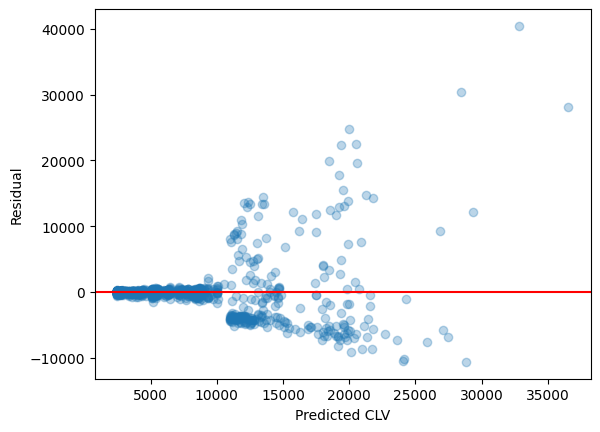

In [37]:
# Residual Analysis

residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel('Predicted CLV'); plt.ylabel('Residual')

<Axes: >

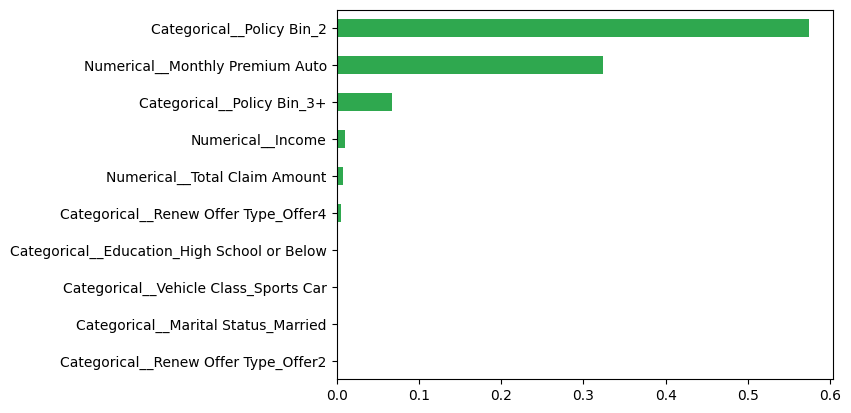

In [41]:
# Feature Importance

importances = pd.Series(
    best_model.named_steps['model'].feature_importances_,
    index=best_model.named_steps['prep'].get_feature_names_out()
).sort_values(ascending=True)

importances.tail(10).plot(kind='barh', color='#2fa84f')

In [44]:
print(f' Up to {round(importances.sort_values(ascending=False).head(3).sum()*100, 3)}% is influenced only by three features')

 Up to 96.559% is influenced only by three features


# Save and Deploy Model

In [45]:
print(best_model.named_steps['model'])

RandomForestRegressor(max_depth=5, min_samples_leaf=10, n_estimators=300,
                      random_state=42)


In [46]:
pickle.dump(best_model, open('model_clv.sav', 'wb'))

In [47]:
# Value Interpretation

ref = clv_df['Customer Lifetime Value']

result_stats = {
    'median': round(ref.median()),
    'p90':    round(ref.quantile(0.90)),
    'p95':    round(ref.quantile(0.95)),
    'p99':    round(ref.quantile(0.99)),
}

result_stats_df = pd.Series(result_stats, name='Threshold CLV').to_frame()

segment_labels = {
    'median': 'Upper half',
    'p90':    'Top 10%',
    'p95':    'Top 5%',
    'p99':    'Top 1%',
}

segment_actions = {
    'median': 'Standard servicing',
    'p90':    'Targeted offers',
    'p95':    'Retention investment',
    'p99':    'Priority retention',
}

result_stats_df['Segment'] = result_stats_df.index.map(segment_labels)
result_stats_df['Action']  = result_stats_df.index.map(segment_actions)

result_stats_df

,Threshold CLV,Segment,Action
median,5838,Upper half,Standard servicing
p90,15641,Top 10%,Targeted offers
p95,21922,Top 5%,Retention investment
p99,36261,Top 1%,Priority retention
